## 1. Setup

In [2]:
import shutil
shutil.rmtree('/root/.cache/torch_extensions', ignore_errors=True)

!pip uninstall -y ninja
!pip install ninja
!which ninja
!ninja --version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 7.1 MB/s eta 0:00:00
/usr/local/bin/ninja
1.13.0.git.kitware.jobserver-pipe-1


In [3]:
import os, math, time
import torch
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from threading import Barrier, Thread
from torch.utils.cpp_extension import load_inline

dim3 = namedtuple('dim3', ['x', 'y', 'z'], defaults=(1, 1))
def cdiv(a, b): return (a + b - 1) // b

cuda_begin = r'''
#include <torch/extension.h>
#include <stdio.h>
#include <c10/cuda/CUDAException.h>
#define CHECK_CUDA(x) TORCH_CHECK(x.device().is_cuda(), #x " must be CUDA")
#define CHECK_CONTIGUOUS(x) TORCH_CHECK(x.is_contiguous(), #x " must be contiguous")
#define CHECK_INPUT(x) CHECK_CUDA(x); CHECK_CONTIGUOUS(x)
__host__ __device__ inline unsigned int cdiv(unsigned int a, unsigned int b) { return (a + b - 1) / b; }
'''

def build(name, cuda_src, cpp_src, funcs):
    return load_inline(name=name, cpp_sources=[cpp_src], cuda_sources=[cuda_src],
                       functions=funcs, extra_cuda_cflags=['-O3'], verbose=False)

def time_kernel(fn, *args, n_warmup=10, n_iters=50):
    for _ in range(n_warmup): fn(*args)
    torch.cuda.synchronize()
    start = torch.cuda.Event(enable_timing=True); end = torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(n_iters): fn(*args)
    end.record(); torch.cuda.synchronize()
    return start.elapsed_time(end) / n_iters

torch.manual_seed(42)
print("Setup OK on:", torch.cuda.get_device_name(0))

Setup OK on: Tesla T4


## 2. Pure-Python matmul


In [4]:
def matmul_py(A, B):
    h, k = A.shape
    k2, w = B.shape
    assert k == k2
    C = torch.zeros(h, w)
    for r in range(h):
        for c in range(w):
            s = 0.
            for i in range(k):
                s += A[r, i].item() * B[i, c].item()
            C[r, c] = s
    return C

A = torch.randn(8, 16); B = torch.randn(16, 8)
assert torch.allclose(matmul_py(A, B), A @ B, atol=1e-4)

## 3. Python-simulated CUDA matmul (one thread per output element)

The "naive" kernel;

Total Memory Wall: Each output element reads `k` elements of A and `k` of B. There are `h*w` output elements. result = `2 * h * w * k = O(N^3)`.


In [5]:
def matmul_naive_py(blockIdx, threadIdx, blockDim, A, B, C, h, w, k):
    r = blockIdx.y * blockDim.y + threadIdx.y
    c = blockIdx.x * blockDim.x + threadIdx.x
    if r >= h or c >= w: return
    s = 0.
    for i in range(k):
        s += A[r*k + i] * B[i*w + c]
    C[r*w + c] = s

def launch_2d(kernel, blocks, tpb, *args):
    "Pretend-launch a 2D grid by nested looping."
    for by in range(blocks.y):
        for bx in range(blocks.x):
            for ty in range(tpb.y):
                for tx in range(tpb.x):
                    kernel(dim3(bx, by), dim3(tx, ty), tpb, *args)
# check
h, k, w = 4, 8, 4
A = torch.randn(h, k); B = torch.randn(k, w); C = torch.zeros(h, w)
tpb = dim3(4, 4)
blocks = dim3(cdiv(w, tpb.x), cdiv(h, tpb.y))
launch_2d(matmul_naive_py, blocks, tpb,
          A.flatten(), B.flatten(), C.flatten(), h, w, k)
assert torch.allclose(C, A @ B, atol=1e-4)

## 4. Naive CUDA matmul



In [6]:
naive_src = cuda_begin + r'''
__global__ void matmul_naive_k(const float* A, const float* B, float* C,
                               int h, int w, int k) {
    int r = blockIdx.y * blockDim.y + threadIdx.y;
    int c = blockIdx.x * blockDim.x + threadIdx.x;
    if (r >= h || c >= w) return;
    float s = 0.0f;
    for (int i = 0; i < k; ++i) s += A[r*k + i] * B[i*w + c];
    C[r*w + c] = s;
}

torch::Tensor matmul_naive(torch::Tensor A, torch::Tensor B) {
    CHECK_INPUT(A); CHECK_INPUT(B);
    int h = A.size(0), k = A.size(1), w = B.size(1);
    TORCH_CHECK(k == B.size(0), "size mismatch");
    auto C = torch::zeros({h, w}, A.options());
    dim3 tpb(16, 16);
    dim3 blocks(cdiv(w, tpb.x), cdiv(h, tpb.y));
    matmul_naive_k<<<blocks, tpb>>>(
        A.data_ptr<float>(), B.data_ptr<float>(), C.data_ptr<float>(), h, w, k);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return C;
}
'''

m_naive = build('matmul_naive', naive_src,
                "torch::Tensor matmul_naive(torch::Tensor A, torch::Tensor B);",
                ['matmul_naive'])
print("compiled OK")

compiled OK


In [7]:
N = 1024
A = torch.randn(N, N, device='cuda')
B = torch.randn(N, N, device='cuda')
assert torch.allclose(m_naive.matmul_naive(A, B), A @ B, atol=1e-2)

ms_naive = time_kernel(m_naive.matmul_naive, A, B)
ms_torch = time_kernel(lambda a, b: a @ b, A, B)
gflops_naive = 2*N**3 / (ms_naive*1e-3) / 1e9
gflops_torch = 2*N**3 / (ms_torch*1e-3) / 1e9
print(f"naive CUDA : {ms_naive:6.2f} ms   {gflops_naive:6.0f} GFLOP/s")
print(f"PyTorch    : {ms_torch:6.2f} ms   {gflops_torch:6.0f} GFLOP/s")
print(f"PyTorch is {ms_naive/ms_torch:.1f}× faster")

naive CUDA :   5.41 ms      397 GFLOP/s
PyTorch    :   0.40 ms     5407 GFLOP/s
PyTorch is 13.6× faster


A Huge Gap!

## 5. Tiling



Imagine computing a 16×16 tile of `C`. Naively, that tile loads:
- 16 rows of A × `k` elements = 16k loads
- 16 columns of B × `k` elements = 16k loads

But these 256 output elements **share** their input data. Every element of A's 16-row slice is used by 16 output elements. **If we load it once into fast memory, we use it 16 times.**

**Tiling procedure** for a `TW × TW` tile:

1. Split the `k` dimension into chunks of size `TW`.
2. For each chunk: cooperatively load a `TW × TW` tile of A and B into **shared memory** (SRAM).
3. Each thread computes its partial dot product from shared memory.
4. Move to next chunk, accumulate.
5. Write the final value.

Global memory loads drop from $O(N^3)$ to $O(N^3 / TW)$. Arithmetic intensity *grows linearly* with the tile width.


## 6. Python simulation of tiling with synchronization


In [8]:
def matmul_tiled_py(blockIdx, threadIdx, blockDim, shared, sync,
                       A, B, C, h, w, k, TW):
    tr, tc = threadIdx.y, threadIdx.x
    r = blockIdx.y * blockDim.y + tr
    c = blockIdx.x * blockDim.x + tc
    As = shared[:TW*TW]            # shared-mem tile for A
    Bs = shared[TW*TW:]            # shared-mem tile for B
    acc = 0.

    for ph in range(cdiv(k, TW)):  # phases over the k dimension
        # 1) Cooperatively load tiles of A and B into shared memory
        As[tr*TW + tc] = A[r*k + ph*TW + tc] if r < h and ph*TW + tc < k else 0.
        Bs[tr*TW + tc] = B[(ph*TW + tr)*w + c] if c < w and ph*TW + tr < k else 0.
        sync.wait()                # __syncthreads()  — wait for all loads

        # 2) Each thread uses the shared tile
        for i in range(TW):
            acc += As[tr*TW + i] * Bs[i*TW + tc]
        sync.wait()                # __syncthreads()  — wait before overwriting

    if r < h and c < w:
        C[r*w + c] = acc

def launch_2d_shared(kernel, blocks, tpb, sh_sz, *args):
    "Launch with simulated shared memory + a barrier per block."
    for by in range(blocks.y):
        for bx in range(blocks.x):
            shared = torch.zeros(sh_sz)
            sync = Barrier(tpb.x * tpb.y)
            threads = [Thread(target=kernel,
                              args=(dim3(bx, by), dim3(tx, ty), tpb,
                                    shared, sync, *args))
                       for ty in range(tpb.y) for tx in range(tpb.x)]
            for t in threads: t.start()
            for t in threads: t.join()

h, k, w, TW = 8, 16, 8, 4
A = torch.randn(h, k); B = torch.randn(k, w); C = torch.zeros(h, w)
launch_2d_shared(matmul_tiled_py,
                 dim3(cdiv(w, TW), cdiv(h, TW)), dim3(TW, TW),
                 TW*TW*2, A.flatten(), B.flatten(), C.flatten(),
                 h, w, k, TW)
assert torch.allclose(C, A @ B, atol=1e-4)


## 7. Tiled CUDA matmul


In [9]:
tiled_src = cuda_begin + r'''
constexpr int TW = 16;

__global__ void matmul_tiled_k(const float* A, const float* B, float* C,
                               int h, int w, int k) {
    __shared__ float As[TW][TW];
    __shared__ float Bs[TW][TW];

    int tr = threadIdx.y, tc = threadIdx.x;
    int r  = blockIdx.y * TW + tr;
    int c  = blockIdx.x * TW + tc;
    float acc = 0.0f;

    for (int ph = 0; ph < cdiv(k, TW); ++ph) {
        // Cooperatively load tiles
        As[tr][tc] = (r < h && ph*TW + tc < k) ? A[r*k + ph*TW + tc] : 0.0f;
        Bs[tr][tc] = (c < w && ph*TW + tr < k) ? B[(ph*TW + tr)*w + c] : 0.0f;
        __syncthreads();

        // Use the shared tiles
        #pragma unroll
        for (int i = 0; i < TW; ++i) acc += As[tr][i] * Bs[i][tc];
        __syncthreads();
    }

    if (r < h && c < w) C[r*w + c] = acc;
}

torch::Tensor matmul_tiled(torch::Tensor A, torch::Tensor B) {
    CHECK_INPUT(A); CHECK_INPUT(B);
    int h = A.size(0), k = A.size(1), w = B.size(1);
    TORCH_CHECK(k == B.size(0), "size mismatch");
    auto C = torch::zeros({h, w}, A.options());
    dim3 tpb(TW, TW);
    dim3 blocks(cdiv(w, TW), cdiv(h, TW));
    matmul_tiled_k<<<blocks, tpb>>>(
        A.data_ptr<float>(), B.data_ptr<float>(), C.data_ptr<float>(), h, w, k);
    C10_CUDA_KERNEL_LAUNCH_CHECK();
    return C;
}
'''

m_tiled = build('matmul_tiled', tiled_src,
                "torch::Tensor matmul_tiled(torch::Tensor A, torch::Tensor B);",
                ['matmul_tiled'])
print("compiled OK")

compiled OK


In [10]:
N = 1024
A = torch.randn(N, N, device='cuda')
B = torch.randn(N, N, device='cuda')
assert torch.allclose(m_tiled.matmul_tiled(A, B), A @ B, atol=1e-2)

## 8. The full benchmark progression

In [11]:
ms_naive = time_kernel(m_naive.matmul_naive, A, B)
ms_tiled = time_kernel(m_tiled.matmul_tiled, A, B)
ms_torch = time_kernel(lambda a, b: a @ b, A, B)

flops = 2 * N**3
print(f"{'kernel':10s}  {'ms':>8s}  {'GFLOP/s':>10s}  speedup vs naive")
print("-" * 50)
for name, ms in [("naive", ms_naive), ("tiled", ms_tiled), ("cuBLAS", ms_torch)]:
    print(f"{name:10s}  {ms:8.2f}  {flops/(ms*1e-3)/1e9:10.0f}  {ms_naive/ms:8.1f}×")

kernel            ms     GFLOP/s  speedup vs naive
--------------------------------------------------
naive           5.48         392       1.0×
tiled           2.71         793       2.0×
cuBLAS          0.42        5152      13.2×


cuBLAS는 레지스터 레벨에서 타일링을 함.


## 9. Put both kernels on the roofline

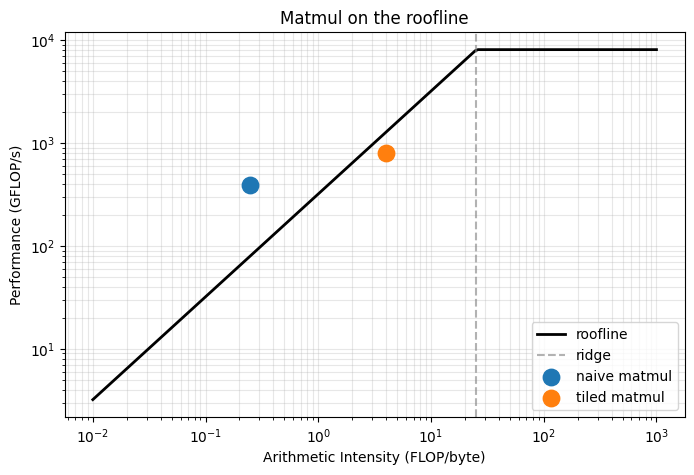

In [12]:
def gflops(ms): return 2*N**3 / (ms*1e-3) / 1e9

# Effective arithmetic intensity — FLOPs per byte ACTUALLY moved through HBM
# Naive: each thread reads 2*k floats from HBM -> total bytes ≈ 2 * h*w*k * 4
#        AI = 2N^3 / (2 N^3 * 4) = 0.25 FLOP/byte
# Tiled (TW=16): each tile is loaded once. Total bytes ≈ 2 * h*w*k * 4 / TW
#        AI = TW / 4 = 4 FLOP/byte (effective)
PEAK_GFLOPS = 8_100
PEAK_BW_GBS = 320

ai_axis = np.logspace(-2, 3, 200)
roof = np.minimum(PEAK_BW_GBS * ai_axis, PEAK_GFLOPS)

points = {
    'naive matmul': (0.25, gflops(ms_naive)),
    'tiled matmul': (4.0,  gflops(ms_tiled)),
}

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ai_axis, roof, 'k-', linewidth=2, label='roofline')
ax.axvline(PEAK_GFLOPS / PEAK_BW_GBS, ls='--', color='gray', alpha=0.6, label='ridge')
for name, (x, y) in points.items():
    ax.scatter(x, y, s=140, label=name, zorder=5)
ax.set_xlabel("Arithmetic Intensity (FLOP/byte)")
ax.set_ylabel("Performance (GFLOP/s)")
ax.set_title("Matmul on the roofline")
ax.legend(loc='lower right')
ax.grid(True, which='both', alpha=0.3)
plt.show()